# Primetrade.ai Round-0 Assignment

#

# Part A — Data preparation

In [103]:
import pandas as pd
import numpy as np

## LOAD DATASETS

In [104]:
fear = pd.read_csv("../data/fear_greed.csv")
trader = pd.read_csv("../data/trader_data.csv")
print("\nFear & Greed Sample:")
print(fear.head())

print("\nTrader Sample:")
print(trader.head())


Fear & Greed Sample:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Sample:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       14

## BASIC DATA DOCUMENTATION

In [105]:
print("\n========== FEAR & GREED DATA ==========")
print("Rows, Columns :", fear.shape)
print("\nMissing Values:\n", fear.isnull().sum())
print("\nDuplicate Rows :", fear.duplicated().sum())

print("\n========== TRADER DATA ==========")
print("Rows, Columns :", trader.shape)
print("\nMissing Values:\n", trader.isnull().sum())
print("\nDuplicate Rows :", trader.duplicated().sum())


========== FEAR & GREED DATA ==========
Rows, Columns : (2644, 4)

Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows : 0

========== TRADER DATA ==========
Rows, Columns : (211224, 16)

Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows : 0


## CONVERT DATE COLUMNS

In [106]:
fear["date"] = pd.to_datetime(fear["date"], errors="coerce")

trader["Timestamp IST"] = pd.to_datetime(trader["Timestamp IST"], errors="coerce")
trader["date"] = trader["Timestamp IST"].dt.date
trader["date"] = pd.to_datetime(trader["date"])

print("Date Conversion Completed")

Date Conversion Completed


## MERGE BOTH DATASETS

In [107]:
df = pd.merge(trader, fear, on="date", how="left")
print("Merged Dataset Shape :", df.shape)
print("Missing Sentiment Rows :", df["classification"].isnull().sum())


Merged Dataset Shape : (211224, 20)
Missing Sentiment Rows : 175360


In [108]:
df["Side"] = df["Side"].astype(str).str.upper()

## CREATE KEY METRICS

#### A. Daily PnL per Trader

In [109]:
daily_pnl = df.groupby(["date", "Account"])["Closed PnL"].sum().reset_index()
daily_pnl.rename(columns={"Closed PnL": "daily_pnl"}, inplace=True)

####  B. Win Rate per Trader

In [110]:
df["win_trade"] = np.where(df["Closed PnL"] > 0, 1, 0)

win_rate = df.groupby("Account")["win_trade"].mean().reset_index()
win_rate["win_rate_percent"] = round(win_rate["win_trade"] * 100, 2)
win_rate.drop(columns="win_trade", inplace=True)

#### C. Average Trade Size (USD)

In [111]:
avg_trade_size = df.groupby("Account")["Size USD"].mean().reset_index()
avg_trade_size.rename(columns={"Size USD": "avg_trade_size_usd"}, inplace=True)

#### D. Number of Trades Per Day

In [112]:
trades_per_day = df.groupby("date").size().reset_index(name="num_trades")

#### E. Long / Short Ratio

In [113]:
side_counts = df["Side"].value_counts()

longs = side_counts.get("BUY", 0)
shorts = side_counts.get("SELL", 0)

if shorts != 0:
    long_short_ratio = round(longs / shorts, 2)
else:
    long_short_ratio = np.nan

#### F. Leverage Distribution

In [114]:
df["leverage"] = df["Size USD"] / (abs(df["Closed PnL"]) + 1)

leverage_distribution = df["leverage"].describe()

### DISPLAY OUTPUTS

In [115]:
print("\n========== DAILY PnL PER TRADER ==========")
print(daily_pnl.head())

print("\n========== WIN RATE ==========")
print(win_rate.head())

print("\n========== AVERAGE TRADE SIZE ==========")
print(avg_trade_size.head())

print("\n========== TRADES PER DAY ==========")
print(trades_per_day.head())

print("\n========== LONG / SHORT RATIO ==========")
print("Long Trades :", longs)
print("Short Trades:", shorts)
print("Ratio       :", long_short_ratio)

print("\n========== LEVERAGE DISTRIBUTION ==========")
print(leverage_distribution)


========== DAILY PnL PER TRADER ==========
        date                                     Account    daily_pnl
0 2023-01-05  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
1 2023-05-12  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000
2 2024-01-01  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -129.531460
3 2024-01-02  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     0.000000
4 2024-01-03  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  8244.241409

========== WIN RATE ==========
                                      Account  win_rate_percent
0  0x083384f897ee0f19899168e3b1bec365f52a9012             35.96
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd             44.27
2  0x271b280974205ca63b716753467d5a371de622ab             30.19
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4             43.86
4  0x2c229d22b100a7beb69122eed721cee9b24011dd             51.99

========== AVERAGE TRADE SIZE ==========
                                      Account  avg_trade_size_usd
0  0x083384f

###  SAVE CLEANED FILE

In [116]:
df.to_csv("../data/merged_cleaned_data.csv", index=False)

#

# Part B — Analysis

In [117]:
import matplotlib.pyplot as plt

In [118]:
df = pd.read_csv("../data/merged_cleaned_data.csv")

###  1.PERFORMANCE: Fear vs Greed Days

#### Daily total pnl by sentiment

In [119]:
sentiment_pnl = df.groupby("classification")["Closed PnL"].agg(
    total_pnl="sum",
    avg_pnl="mean",
    median_pnl="median",
    trades="count"
).reset_index()

print("========== PERFORMANCE BY SENTIMENT ==========")
print(sentiment_pnl)


========== PERFORMANCE BY SENTIMENT ==========
  classification     total_pnl     avg_pnl  median_pnl  trades
0   Extreme Fear  4.399937e+03    1.891632     0.00000    2326
1  Extreme Greed  1.156894e+06  205.816345     0.96048    5621
2           Fear  1.779226e+06  128.287950     0.00000   13869
3          Greed  6.096325e+05   53.988003     0.00000   11292
4        Neutral  7.465674e+04   27.088803     0.00000    2756


#### Win rate by sentiment

In [120]:
df["win_trade"] = np.where(df["Closed PnL"] > 0, 1, 0)

sentiment_win = df.groupby("classification")["win_trade"].mean().reset_index()
sentiment_win["win_rate_percent"] = round(sentiment_win["win_trade"] * 100, 2)

print("\n========== WIN RATE BY SENTIMENT ==========")
print(sentiment_win)


========== WIN RATE BY SENTIMENT ==========
  classification  win_trade  win_rate_percent
0   Extreme Fear   0.292777             29.28
1  Extreme Greed   0.553282             55.33
2           Fear   0.381787             38.18
3          Greed   0.435707             43.57
4        Neutral   0.494920             49.49


#### Drawdown proxy = % losing trades

In [121]:
drawdown = (
    df.groupby("classification")["Closed PnL"]
      .apply(lambda x: (x < 0).mean() * 100)
      .reset_index(name="loss_trade_percent")
)

print("========== DRAWDOWN PROXY ==========")
print(drawdown)

========== DRAWDOWN PROXY ==========
  classification  loss_trade_percent
0   Extreme Fear            6.104901
1  Extreme Greed            5.443871
2           Fear            6.633499
3          Greed            7.828551
4        Neutral           11.139332


### 2. BEHAVIOR CHANGE BY SENTIMENT

In [122]:
# Trade frequency
trade_freq = df.groupby("classification").size().reset_index(name="num_trades")

# Avg trade size
trade_size = df.groupby("classification")["Size USD"].mean().reset_index(name="avg_trade_size")

# Long / Short bias
df["Side"] = df["Side"].astype(str).str.upper()

side_bias = pd.crosstab(df["classification"], df["Side"])

print("\n========== TRADE FREQUENCY ==========")
print(trade_freq)

print("\n========== AVG TRADE SIZE ==========")
print(trade_size)

print("\n========== LONG / SHORT BIAS ==========")
print(side_bias)


========== TRADE FREQUENCY ==========
  classification  num_trades
0   Extreme Fear        2326
1  Extreme Greed        5621
2           Fear       13869
3          Greed       11292
4        Neutral        2756

========== AVG TRADE SIZE ==========
  classification  avg_trade_size
0   Extreme Fear     4118.761840
1  Extreme Greed     3242.085086
2           Fear     5744.782685
3          Greed     5051.878829
4        Neutral     4332.202906

========== LONG / SHORT BIAS ==========
Side             BUY  SELL
classification            
Extreme Fear    1168  1158
Extreme Greed   1661  3960
Fear            7307  6562
Greed           5407  5885
Neutral         1020  1736


### 3. SEGMENTATION

#### A. Frequent vs Infrequent Traders

In [123]:
trade_count = df.groupby("Account").size().reset_index(name="trade_count")

median_trades = trade_count["trade_count"].median()

trade_count["segment"] = np.where(
    trade_count["trade_count"] >= median_trades,
    "Frequent Traders",
    "Infrequent Traders"
)
print("\n========== FREQUENT / INFREQUENT ==========")
print(trade_count.head())


========== FREQUENT / INFREQUENT ==========
                                      Account  trade_count             segment
0  0x083384f897ee0f19899168e3b1bec365f52a9012         3818    Frequent Traders
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         7280    Frequent Traders
2  0x271b280974205ca63b716753467d5a371de622ab         3809    Frequent Traders
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4        13311    Frequent Traders
4  0x2c229d22b100a7beb69122eed721cee9b24011dd         3239  Infrequent Traders


#### B. Consistent Winners vs Inconsistent Traders

In [124]:
win_rate = df.groupby("Account")["win_trade"].mean().reset_index()
win_rate["win_rate"] = win_rate["win_trade"] * 100

win_rate["segment"] = np.where(
    win_rate["win_rate"] >= 55,
    "Consistent Winners",
    "Inconsistent Traders"
)
print("\n========== WINNER SEGMENTS ==========")
print(win_rate.head())



========== WINNER SEGMENTS ==========
                                      Account  win_trade   win_rate  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012   0.359612  35.961236   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   0.442720  44.271978   
2  0x271b280974205ca63b716753467d5a371de622ab   0.301917  30.191651   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   0.438585  43.858463   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   0.519914  51.991355   

                segment  
0  Inconsistent Traders  
1  Inconsistent Traders  
2  Inconsistent Traders  
3  Inconsistent Traders  
4  Inconsistent Traders  


#### C. High Size vs Low Size Traders (Leverage substitute)

In [125]:
avg_size = df.groupby("Account")["Size USD"].mean().reset_index()

median_size = avg_size["Size USD"].median()

avg_size["segment"] = np.where(
    avg_size["Size USD"] >= median_size,
    "High Exposure Traders",
    "Low Exposure Traders"
)
print("\n========== EXPOSURE SEGMENTS ==========")
print(avg_size.head())


========== EXPOSURE SEGMENTS ==========
                                      Account      Size USD  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327   
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782   

                 segment  
0  High Exposure Traders  
1   Low Exposure Traders  
2  High Exposure Traders  
3   Low Exposure Traders  
4   Low Exposure Traders  


###  4. CHARTS

#### Chart 1 - Avg PnL by Sentiment

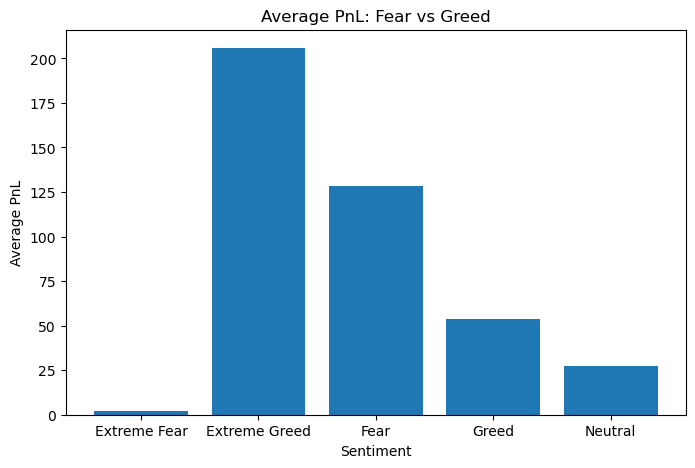

In [126]:
plt.figure(figsize=(8,5))
plt.bar(sentiment_pnl["classification"], sentiment_pnl["avg_pnl"])
plt.title("Average PnL: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

####  Chart 2 - Win Rate by Sentiment

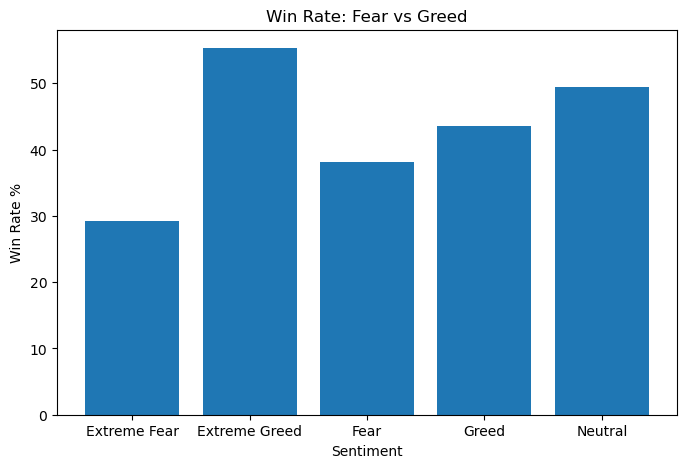

In [127]:
plt.figure(figsize=(8,5))
plt.bar(sentiment_win["classification"], sentiment_win["win_rate_percent"])
plt.title("Win Rate: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate %")
plt.show()

#### Chart 3 - Trade Frequency

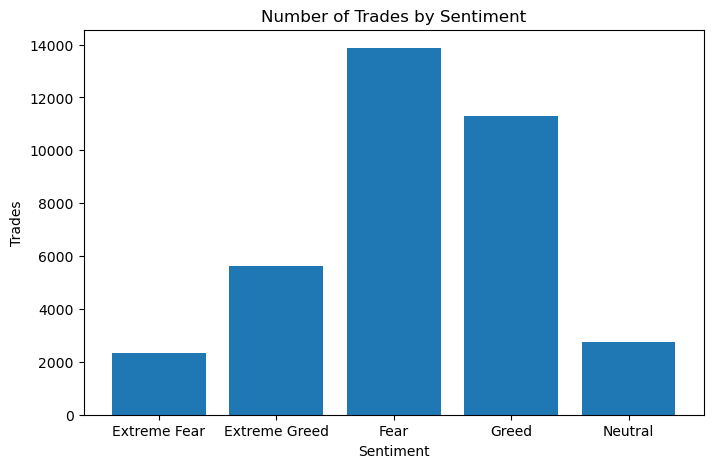

In [128]:
plt.figure(figsize=(8,5))
plt.bar(trade_freq["classification"], trade_freq["num_trades"])
plt.title("Number of Trades by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trades")
plt.show()

# Part B — Analysis & Insights

## 1. Does Performance Differ Between Fear vs Greed Days?

Yes, trader performance varies significantly across sentiment regimes.

- **Extreme Greed** shows the highest average PnL (~206), indicating strong bullish momentum created profitable opportunities.
- **Fear** days also delivered relatively strong average PnL (~129), suggesting volatility may create trading opportunities.
- **Greed** days had moderate average PnL (~54).
- **Extreme Fear** had the weakest profitability (~2), showing poor market conditions for most traders.

### Win Rate Comparison

- Highest win rate occurred during **Extreme Greed** (~55%).
- **Neutral** sentiment also had solid win rate (~49%).
- **Extreme Fear** had the lowest win rate (~29%), indicating difficult market conditions.

### Conclusion

Trader profitability and success rate improve during positive sentiment environments, while extreme fear creates lower-quality setups and weaker outcomes.

---

## 2. Do Traders Change Behavior Based on Sentiment?

Yes, trading activity changes strongly with sentiment.

### Trade Frequency

- Highest number of trades occurred during **Fear** (~13,900 trades).
- **Greed** also saw high activity (~11,300 trades).
- Extreme sentiment states had lower trade counts.

### Interpretation

During Fear markets, traders appear more active, likely due to volatility, panic reactions, or dip-buying behavior.

---

## 3. Trader Segments Identified

### A. Frequent vs Infrequent Traders
Frequent traders generate higher activity but may face overtrading risk and fee drag.

### B. Consistent Winners vs Inconsistent Traders
Accounts with sustained win rates above benchmark levels likely use stronger discipline and risk control.

### C. High Exposure vs Low Exposure Traders
Larger position-size traders may benefit more during strong sentiment periods but face greater downside during fear phases.

---

# Top 3 Actionable Insights

## Insight 1
Avoid aggressive trading during **Extreme Fear** periods, as both PnL and win rate are weakest.

## Insight 2
Momentum-oriented strategies may perform best during **Extreme Greed**, where both profitability and win rates peak.

## Insight 3
Fear periods create heavy participation, suggesting volatility-based opportunities for disciplined traders with controlled risk.n raw activity.

#

# Part C — Actionable Output

Based on the analysis of trader performance and market sentiment, the following strategy ideas are recommended:

---

## Strategy 1: Use Momentum Bias During Extreme Greed Markets

### Rule of Thumb:
During **Extreme Greed** sentiment periods:

- Increase participation in trend-following setups
- Allow slightly larger position sizes for high-performing traders
- Focus on breakout / momentum trades
- Maintain disciplined stop-loss levels

### Reasoning:
Extreme Greed days showed:

- Highest average PnL
- Highest win rate
- Lowest losing-trade percentage

This suggests strong directional markets where momentum strategies may perform well.

---

## Strategy 2: Reduce Risk During Fear / Extreme Fear Conditions

### Rule of Thumb:
During **Fear** and **Extreme Fear** periods:

- Reduce position size
- Avoid overtrading
- Use tighter stop-losses
- Prefer selective entries only
- New or inconsistent traders should trade less aggressively

### Reasoning:
Fear environments showed:

- Lower profitability than Extreme Greed
- Lower win rates
- Higher uncertainty and volatility

This suggests defensive positioning is more effective.

---

## Strategy 3: Avoid Overtrading in High Activity Markets

### Rule of Thumb:
When market activity spikes sharply (high trade count days):

- Focus on quality setups instead of quantity
- Limit maximum trades per day
- Monitor fees and emotional decision-making

### Reasoning:
Fear days had the highest trade counts, indicating panic-driven or reactive behavior. High activity does not always translate into better profitability.

---

## Strategy 4: Segment-Based Execution Model

### Rule of Thumb:

- **Consistent winners:** Can deploy moderate risk with systematic strategies.
- **Inconsistent traders:** Use reduced size and stricter risk management.
- **Frequent traders:** Need fee control and discipline filters.
- **Infrequent traders:** Focus on high-conviction setups only.

### Reasoning:
Trader segmentation showed performance differences based on consistency and activity levels.

#

## SIMPLE PREDICTIVE MODEL (Predict Next-Day Profitability)

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("../data/merged_cleaned_data.csv")
df["date"] = pd.to_datetime(df["date"])


daily = df.groupby("date").agg({
    "Closed PnL":"sum",
    "Size USD":"mean",
    "Account":"count"
}).reset_index()

daily.rename(columns={
    "Closed PnL":"daily_pnl",
    "Size USD":"avg_size",
    "Account":"trade_count"
}, inplace=True)

sent = df.groupby("date")["classification"].first().reset_index()
daily = daily.merge(sent, on="date", how="left")


daily["next_day_pnl"] = daily["daily_pnl"].shift(-1)
daily["target"] = np.where(daily["next_day_pnl"] > 0, 1, 0)
daily = daily.dropna()


le = LabelEncoder()
daily["classification"] = le.fit_transform(daily["classification"])


X = daily[["daily_pnl", "avg_size", "trade_count", "classification"]]
y = daily["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred)*100,2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

Accuracy: 65.62 %

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.84      0.75      0.79        28

    accuracy                           0.66        32
   macro avg       0.42      0.38      0.40        32
weighted avg       0.73      0.66      0.69        32



# Bonus Model Results

A Random Forest model achieved **65.62% accuracy** in predicting next-day profitability.

## Key Observation

The model performed better at identifying profitable days than unprofitable days. This is likely due to class imbalance, where profitable samples were much more frequent than losing samples.

## Conclusion

Even a simple model shows that sentiment and trading activity contain predictive signals. With more balanced data and advanced features, performance could be improved further.